<>:87: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\D'
C:\Users\vinso\AppData\Local\Temp\ipykernel_6552\2376056725.py:87: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Delta de Qualification $\Delta Q = |P_{Qualif1} - P_{Qualif2}|$", fontsize=12)



--- NOUVEAU MODÈLE (Filtré entre 0.15 et 0.85) ---
P_Draw(x) = -0.2637*x² + 0.0634*x + 0.2645
RMSE (Écart-type du bruit) : 0.0154

--- ANALYSE DU BRUIT MULTIPLICATIF ---
Écart-type de l'erreur relative : 0.0680
Soit un bruit d'environ ± 6.8% autour de la prédiction cible.


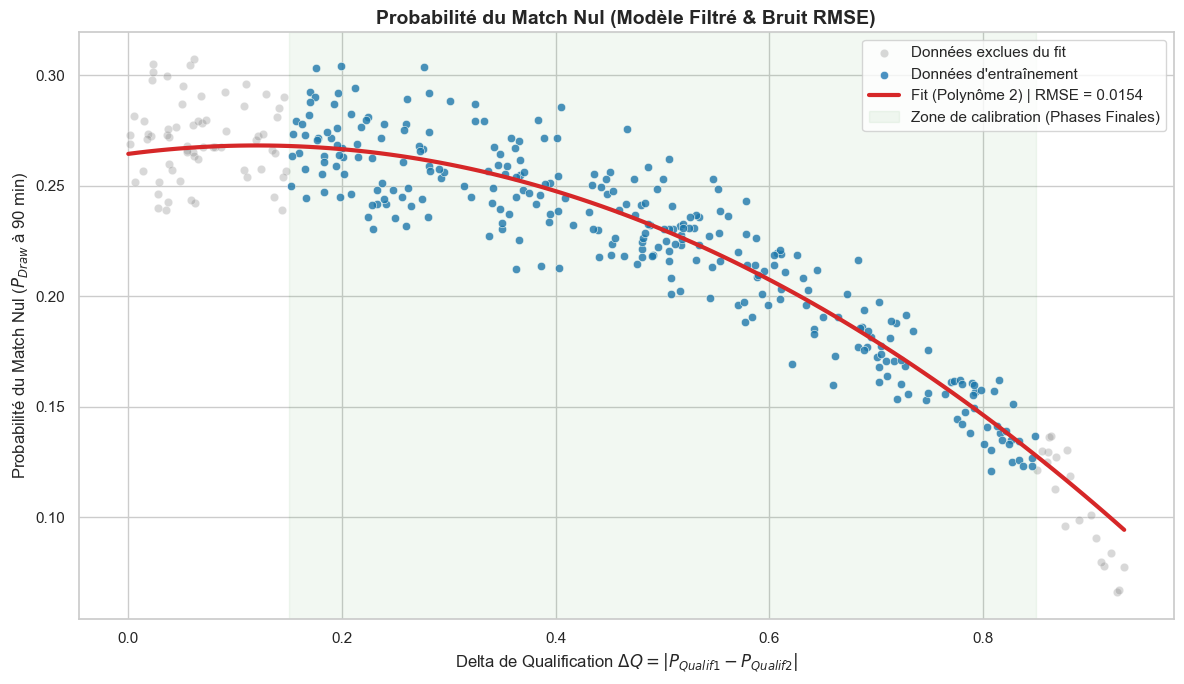

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.metrics import mean_squared_error

# Configuration du style
sns.set_theme(style="whitegrid")

def calculate_true_probas(h, d, a):
    inv = 1.0 / np.array([h, d, a])
    return inv / np.sum(inv, axis=0)

# ==========================================
# 1 & 2 & 3. CHARGEMENT ET PREP (Inchangé)
# ==========================================
sys.path.append(str(Path.cwd().parent))
data_path_csv = Path.cwd().parent / "data" / "Scraped" / "England_2023-2024.csv"
df = pd.read_csv(data_path_csv).dropna(subset=['AvgCH', 'AvgCD', 'AvgCA'])

probas_close = calculate_true_probas(df['AvgCH'], df['AvgCD'], df['AvgCA'])
df['True_P_Draw'] = probas_close[1]

inv_h = 1.0 / df['AvgCH']
inv_a = 1.0 / df['AvgCA']
df['P_Qualif_Home'] = inv_h / (inv_h + inv_a)
df['P_Qualif_Away'] = inv_a / (inv_h + inv_a)
df['Delta_Qualif'] = np.abs(df['P_Qualif_Home'] - df['P_Qualif_Away'])

# ==========================================
# 4. FILTRAGE ET MODÉLISATION (LES NOUVEAUTÉS)
# ==========================================
# On isole les données "cohérentes" avec une phase finale de CDM
df_filtered = df[(df['Delta_Qualif'] >= 0.15) & (df['Delta_Qualif'] <= 0.85)].copy()

# Régression quadratique sur les données filtrées uniquement
coefs = np.polyfit(df_filtered['Delta_Qualif'], df_filtered['True_P_Draw'], 2)
poly_function = np.poly1d(coefs)

# Calcul du RMSE sur cet échantillon
y_true = df_filtered['True_P_Draw']
y_pred = poly_function(df_filtered['Delta_Qualif'])
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# ==========================================
# CALCUL DU BRUIT MULTIPLICATIF
# ==========================================
y_true = df_filtered['True_P_Draw']
y_pred = poly_function(df_filtered['Delta_Qualif'])

# Calcul de l'erreur relative pour chaque match
relative_errors = (y_true - y_pred) / y_pred

# Le RMSE multiplicatif est l'écart-type de ces erreurs
rmse_mult = np.std(relative_errors)

print("\n--- NOUVEAU MODÈLE (Filtré entre 0.15 et 0.85) ---")
print(f"P_Draw(x) = {coefs[0]:.4f}*x² + {coefs[1]:.4f}*x + {coefs[2]:.4f}")
print(f"RMSE (Écart-type du bruit) : {rmse:.4f}")
print("\n--- ANALYSE DU BRUIT MULTIPLICATIF ---")
print(f"Écart-type de l'erreur relative : {rmse_mult:.4f}")
print(f"Soit un bruit d'environ ± {rmse_mult * 100:.1f}% autour de la prédiction cible.")

# ==========================================
# 5. VISUALISATION
# ==========================================
plt.figure(figsize=(12, 7))

# Plot des données exclues (en gris, pour visualiser ce qu'on a coupé)
df_excluded = df[(df['Delta_Qualif'] < 0.15) | (df['Delta_Qualif'] > 0.85)]
sns.scatterplot(x='Delta_Qualif', y='True_P_Draw', data=df_excluded, color='gray', alpha=0.3, label='Données exclues du fit')

# Plot des données filtrées (utilisées pour le fit)
sns.scatterplot(x='Delta_Qualif', y='True_P_Draw', data=df_filtered, color='#1f77b4', alpha=0.8, edgecolor='w', label='Données d\'entraînement')

# La ligne de régression (tracée sur tout l'axe pour voir le comportement)
x_line = np.linspace(0, df['Delta_Qualif'].max(), 100)
plt.plot(x_line, poly_function(x_line), color='#d62728', linewidth=3, 
         label=f'Fit (Polynôme 2) | RMSE = {rmse:.4f}')

# Zone de focus grisée pour bien montrer le filtre
plt.axvspan(0.15, 0.85, color='green', alpha=0.05, label='Zone de calibration (Phases Finales)')

plt.title("Probabilité du Match Nul (Modèle Filtré & Bruit RMSE)", fontsize=14, fontweight='bold')
plt.xlabel("Delta de Qualification $\Delta Q = |P_{Qualif1} - P_{Qualif2}|$", fontsize=12)
plt.ylabel("Probabilité du Match Nul ($P_{Draw}$ à 90 min)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()